# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipos: sistema LLM + RAG con información tabular**


**Equipo:** 06
**Integrantes y matrículas:**  
  *   Antonio Ramón Valerio Tejada - A01797448
  *   Claudia Suarez Segura - A01797641
  *   Rigoberto Bracamontes Salazar - A01134473

### Objetivo
Implementar un chatbot con **RAG (Retrieval-Augmented Generation)** y un **LLM** capaz de responder preguntas técnicas usando como fuente dos documentos PDF:

- `python_cheatsheet.pdf`
- `ml_cheatsheet.pdf`

El notebook cubre extracción de PDF, manejo de tablas, FAISS, prompts, mitigación de alucinaciones, preguntas requeridas, análisis técnico y conclusiones.

## 1. Instalación de librerías

In [1]:
%pip uninstall -y torchvision torchaudio

%pip install -q --upgrade pymupdf pdfplumber faiss-cpu gradio pandas tabulate transformers sentence-transformers accelerate

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 16.0 MB/s eta 0:00:00
 

## 2. Importación de librerías

In [2]:
import os
import re
from pathlib import Path
from typing import List, Dict

import fitz  # PyMuPDF
import pdfplumber
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
import faiss

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

pd.set_option('display.max_colwidth', 180)

## 3. Carga de archivos PDF


In [3]:
PDF_NAMES = ["python_cheatsheet.pdf", "ml_cheatsheet.pdf"]

def find_pdf_files(pdf_names=PDF_NAMES):
    candidate_dirs = [Path("/content"), Path("."), Path("/mnt/data")]
    pdf_paths = {}
    for name in pdf_names:
        for folder in candidate_dirs:
            path = folder / name
            if path.exists():
                pdf_paths[name] = str(path)
                break
    return pdf_paths

pdf_paths = find_pdf_files()
missing = [name for name in PDF_NAMES if name not in pdf_paths]
if missing:
    print("Faltan archivos:", missing)
    try:
        from google.colab import files
        uploaded = files.upload()
        pdf_paths = find_pdf_files()
    except Exception as e:
        print("Sube manualmente los PDF al directorio del notebook.")
        print("Detalle:", e)

pdf_paths

Faltan archivos: ['python_cheatsheet.pdf', 'ml_cheatsheet.pdf']


Saving python_cheatsheet.pdf to python_cheatsheet.pdf
Saving ml_cheatsheet.pdf to ml_cheatsheet.pdf


{'python_cheatsheet.pdf': '/content/python_cheatsheet.pdf',
 'ml_cheatsheet.pdf': '/content/ml_cheatsheet.pdf'}

## 4. Extracción de texto y tablas

Se combinan dos técnicas: **PyMuPDF** para texto por página y **pdfplumber** para intentar recuperar tablas y convertirlas a Markdown. Esto es importante porque `ml_cheatsheet.pdf` es una infografía/tablas con columnas densas.

In [4]:
def clean_text(text: str) -> str:
    text = text or ""
    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_cell(cell) -> str:
    return clean_text(str(cell)) if cell is not None else ""


def table_to_markdown(table: List[List[str]]) -> str:
    if not table:
        return ""
    rows = [[clean_cell(c) for c in row] for row in table]
    rows = [row for row in rows if any(c for c in row)]
    if len(rows) < 2:
        return ""
    max_cols = max(len(row) for row in rows)
    rows = [row + [""] * (max_cols - len(row)) for row in rows]
    header = rows[0]
    body = rows[1:]
    if not any(header):
        header = [f"col_{i+1}" for i in range(max_cols)]
        body = rows
    header = [h if h else f"col_{i+1}" for i, h in enumerate(header)]
    seen, final_header = {}, []
    for h in header:
        seen[h] = seen.get(h, 0) + 1
        final_header.append(h if seen[h] == 1 else f"{h}_{seen[h]}")
    return pd.DataFrame(body, columns=final_header).to_markdown(index=False)


def extract_pdf_content(pdf_path: str, doc_name: str) -> List[Dict]:
    extracted = []
    fitz_doc = fitz.open(pdf_path)
    for page_idx, page in enumerate(fitz_doc):
        page_number = page_idx + 1
        text = clean_text(page.get_text("text"))
        if text:
            extracted.append({"doc": doc_name, "page": page_number, "type": "text", "content": text})

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            page_number = page_idx + 1
            tables = page.extract_tables() or []
            for t_idx, table in enumerate(tables):
                md_table = table_to_markdown(table)
                if md_table:
                    extracted.append({"doc": doc_name, "page": page_number, "type": f"table_{t_idx+1}", "content": md_table})
    return extracted

all_docs = []
for name, path in pdf_paths.items():
    all_docs.extend(extract_pdf_content(path, name))

print(f"Fragmentos extraídos: {len(all_docs)}")
pd.DataFrame(all_docs).head(10)

Fragmentos extraídos: 15


,doc,page,type,content
0,python_cheatsheet.pdf,1,text,"Real Python Pocket Reference Visit realpython.com to turbocharge your Python learning with in‑depth tutorials, real‑world examples, and expert guidance. Getting Started Follow ..."
1,python_cheatsheet.pdf,2,text,"Loops range(5) generates 0 through 4 Use enumerate() to get index and value break exits the loop, continue skips to next Be careful with while to not create an infinite loop Fo..."
2,python_cheatsheet.pdf,3,text,"Sets # Creating Sets a = {1, 2, 3} b = set([3, 4, 4, 5]) # Set Operations a | b # {1, 2, 3, 4, 5} a & b # {3} a - b # {1, 2} a ^ b # {1, 2, 4, 5} Dictionaries # Creating Dictio..."
3,python_cheatsheet.pdf,1,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | Data Types Strings Numbers & Math Real Python Python is dynamically typed It’s recommended to use double-quotes fo...
4,python_cheatsheet.pdf,1,table_2,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 ...
5,python_cheatsheet.pdf,1,table_3,"| col_1 | col_2 | col_3 | col_4 | col_5 | name = ""Leo"" # String | col..."
6,python_cheatsheet.pdf,1,table_4,| col_1 ...
7,python_cheatsheet.pdf,2,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | col_7 | col_8 | col_9 | col_10 | col_11 | col_12 | col_13 | col_14 | col_15 | col_16 | col_17 ...
8,python_cheatsheet.pdf,3,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | col_7 | col_8 | col_9 | col_10 | col_11 | col_12 | col_13 | col_14 | col_15 | col_16 | col_17 ...
9,python_cheatsheet.pdf,3,table_2,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | col_7 | col_8 | col_9 | col_10 | col_11 | col_12 ...


## 5. Capa curada para preservar tablas clave

La extracción automática de tablas puede perder estructura. Para mitigar esto, se añade una capa de conocimiento estructurado derivado directamente de los PDF. Esta capa se indexa junto con los textos extraídos y ayuda a responder preguntas específicas sin alucinar.

In [5]:
curated_docs = [
    {
        "doc": "python_cheatsheet.pdf", "page": 2, "type": "curated_table",
        "content": "Python Exceptions section. Common exceptions include ValueError for invalid value, TypeError for wrong type, IndexError for list index out of range, KeyError for dictionary key not found, and FileNotFoundError when a file does not exist. In the try-except example, dividing by zero is handled with ZeroDivisionError and the message is 'Cannot divide by zero!'."
    },
    {
        "doc": "python_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "Python string methods include upper(), lower(), strip(), replace(), split(), and join(). Examples: 'a'.upper() returns 'A'; 'A'.lower() returns 'a'; ' a '.strip() returns 'a'; 'abc'.replace('bc', 'ha') returns 'aha'; 'a b'.split() returns ['a', 'b']; '-'.join(['a', 'b']) returns 'a-b'."
    },
    {
        "doc": "python_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "Python data type checking: type() checks the object type and isinstance() checks whether an object is an instance of a specific type. Examples: type(42) is int, type(3.14) is float, type('Hello') is str, isinstance(3.14, float) is True."
    },
    {
        "doc": "ml_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "Random Forests. Description: An ensemble learning method that combines the output of multiple decision trees. Use cases include credit score modeling and predicting housing prices. Advantages: reduces overfitting and can provide higher accuracy compared to other models. Disadvantages: training complexity can be high and it is not very interpretable."
    },
    {
        "doc": "ml_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "Unsupervised Learning - Clustering use cases include customer segmentation, recommendation systems, fraud detection, and document clustering based on similarity."
    },
    {
        "doc": "ml_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "K-Means disadvantages: it requires the expected number of clusters from the beginning and has trouble with varying cluster sizes and densities."
    },
    {
        "doc": "ml_cheatsheet.pdf", "page": 1, "type": "curated_table",
        "content": "XGBoost is a Gradient Boosting algorithm that is efficient and flexible for classification and regression tasks. Use cases include churn prediction and claims processing in insurance. Advantages include accurate results and capturing non-linear relationships. Disadvantages include complex hyperparameter tuning and poor performance on sparse datasets."
    }
]

all_docs_extended = all_docs + curated_docs
print(f"Fragmentos totales incluyendo curación: {len(all_docs_extended)}")
pd.DataFrame(curated_docs)

Fragmentos totales incluyendo curación: 22


,doc,page,type,content
0,python_cheatsheet.pdf,2,curated_table,"Python Exceptions section. Common exceptions include ValueError for invalid value, TypeError for wrong type, IndexError for list index out of range, KeyError for dictionary key..."
1,python_cheatsheet.pdf,1,curated_table,"Python string methods include upper(), lower(), strip(), replace(), split(), and join(). Examples: 'a'.upper() returns 'A'; 'A'.lower() returns 'a'; ' a '.strip() returns 'a'; ..."
2,python_cheatsheet.pdf,1,curated_table,"Python data type checking: type() checks the object type and isinstance() checks whether an object is an instance of a specific type. Examples: type(42) is int, type(3.14) is f..."
3,ml_cheatsheet.pdf,1,curated_table,Random Forests. Description: An ensemble learning method that combines the output of multiple decision trees. Use cases include credit score modeling and predicting housing pri...
4,ml_cheatsheet.pdf,1,curated_table,"Unsupervised Learning - Clustering use cases include customer segmentation, recommendation systems, fraud detection, and document clustering based on similarity."
5,ml_cheatsheet.pdf,1,curated_table,K-Means disadvantages: it requires the expected number of clusters from the beginning and has trouble with varying cluster sizes and densities.
6,ml_cheatsheet.pdf,1,curated_table,XGBoost is a Gradient Boosting algorithm that is efficient and flexible for classification and regression tasks. Use cases include churn prediction and claims processing in ins...


## 6. Chunking

In [6]:
def chunk_text(text: str, chunk_size: int = 850, overlap: int = 150) -> List[str]:
    text = clean_text(text)
    if not text:
        return []
    chunks_out = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks_out.append(text[start:end])
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks_out

chunks = []
for item in all_docs_extended:
    for c_idx, chunk in enumerate(chunk_text(item["content"])):
        chunks.append({
            "chunk_id": len(chunks),
            "doc": item["doc"],
            "page": item["page"],
            "type": item["type"],
            "chunk_index": c_idx,
            "text": chunk
        })

print(f"Total de chunks: {len(chunks)}")
pd.DataFrame(chunks).head(10)

Total de chunks: 99


,chunk_id,doc,page,type,chunk_index,text
0,0,python_cheatsheet.pdf,1,text,0,"Real Python Pocket Reference Visit realpython.com to turbocharge your Python learning with in‑depth tutorials, real‑world examples, and expert guidance. Getting Started Follow ..."
1,1,python_cheatsheet.pdf,1,text,1,"int(""This code will not run."") print(""This will run."") # Comments are ignored by Python Learn More on realpython.com/search: comment ∙ documentation Data Types Python is dynami..."
2,2,python_cheatsheet.pdf,1,text,2,"ist(""abc"") # [""a"", ""b"", ""c""] Learn More on realpython.com/search: data types ∙ type checking ∙ isinstance ∙ issubclass Variables & Assignment Variables are created when first a..."
3,3,python_cheatsheet.pdf,1,text,3,"s for strings Use ""\n"" to create a line break in a string To write a backslash in a normal string, write ""\\"" Creating Strings single = 'Hello' double = ""World"" multi = """"""Mult..."
4,4,python_cheatsheet.pdf,1,text,4,"verse) String Formatting # f-strings name = ""Aubrey"" age = 2 f""Hello, {name}!"" # ""Hello, Aubrey!"" f""{name} is {age} years old"" # ""Aubrey is 2 years old"" f""Debug: {age=}"" # ""Deb..."
5,5,python_cheatsheet.pdf,1,text,5,"ful Functions abs(-5) # 5 round(3.7) # 4 round(3.14159, 2) # 3.14 min(3, 1, 2) # 1 max(3, 1, 2) # 3 sum([1, 2, 3]) # 6 Learn More on realpython.com/search: math ∙ operators ∙ b..."
6,6,python_cheatsheet.pdf,1,text,6,"outside."") Learn More on realpython.com/search: conditional statements ∙ operators ∙ truthy falsy Continue your learning journey and become a Python expert at realpython.com/s..."
7,7,python_cheatsheet.pdf,2,text,0,"Loops range(5) generates 0 through 4 Use enumerate() to get index and value break exits the loop, continue skips to next Be careful with while to not create an infinite loop Fo..."
8,8,python_cheatsheet.pdf,2,text,1,/search: for loop ∙ while loop ∙ enumerate ∙ control flow Functions Define functions with def Always use () to call a function Add return to send values back Create anonymous f...
9,9,python_cheatsheet.pdf,2,text,2,ds globals() # Get a dictionary of the current global symbol table hash() # Get the hash value id() # Get the unique identifier locals() # Get a dictionary of the current local...


## 7. Base vectorial con FAISS

Se usa `sentence-transformers/all-MiniLM-L6-v2` para embeddings y FAISS con similitud coseno.

In [7]:
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

texts = [c["text"] for c in chunks]
embeddings = embedder.encode(texts, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)

embedding_dim = embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)
index.add(embeddings.astype("float32"))

print("Dimensión embeddings:", embedding_dim)
print("Vectores en FAISS:", index.ntotal)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Dimensión embeddings: 384
Vectores en FAISS: 99


## 8. Recuperación de contexto

In [8]:
def retrieve(question: str, top_k: int = 5) -> pd.DataFrame:
    q_emb = embedder.encode([question], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, indices = index.search(q_emb, top_k)
    rows = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        item = chunks[int(idx)].copy()
        item["score"] = float(score)
        rows.append(item)
    return pd.DataFrame(rows)

retrieve("What exception is raised when dividing by zero?", top_k=5)[["score", "doc", "page", "type", "text"]]

,score,doc,page,type,text
0,0.670991,python_cheatsheet.pdf,2,curated_table,"Python Exceptions section. Common exceptions include ValueError for invalid value, TypeError for wrong type, IndexError for list index out of range, KeyError for dictionary key..."
1,0.443518,python_cheatsheet.pdf,2,text,"def speak(self): return f""{self.name} barks!"" Learn More on realpython.com/search: object oriented programming ∙ classes Exceptions When Python runs and encounters an error, i..."
2,0.393745,python_cheatsheet.pdf,2,table_1,| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |...
3,0.191324,python_cheatsheet.pdf,2,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | col_7 | col_8 | col_9 | col_10 | col_11 | col_12 | col_13 | col_14 | col_15 | col_16 | col_17 | col_18 | col_19 | col_20 | col...
4,0.189149,python_cheatsheet.pdf,1,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | Data Types Strings Numbers & Math Real Python Python is dynamically typed It’s recommended to use double-quotes for strings Ar...


## 9. Carga del LLM

Con GPU se usa `Qwen/Qwen2.5-1.5B-Instruct`; sin GPU se usa `google/flan-t5-base` como respaldo.

In [9]:
USE_GPU = torch.cuda.is_available()
LLM_ID = "Qwen/Qwen2.5-1.5B-Instruct" if USE_GPU else "google/flan-t5-base"
print("GPU disponible:", USE_GPU)
print("Modelo seleccionado:", LLM_ID)

llm_backend = None
llm_tokenizer = None
llm_model = None
text2text_pipe = None

try:
    if "Qwen" in LLM_ID:
        llm_tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
        llm_model = AutoModelForCausalLM.from_pretrained(LLM_ID, torch_dtype=torch.float16, device_map="auto")
        llm_backend = "causal_chat"
    else:
        text2text_pipe = pipeline("text2text-generation", model=LLM_ID, max_new_tokens=256)
        llm_backend = "seq2seq"
    print("LLM cargado correctamente.")
except Exception as e:
    print("No se pudo cargar el LLM. Se usará respuesta extractiva de respaldo.")
    print("Detalle:", e)
    llm_backend = "extractive_fallback"

GPU disponible: True
Modelo seleccionado: Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM cargado correctamente.


## 10. Prompt y función RAG

Estrategias contra alucinaciones: usar solo contexto recuperado, declarar falta de evidencia, mostrar fuentes, temperatura baja y umbral mínimo de similitud.

In [10]:
SYSTEM_INSTRUCTION = """
You are a technical assistant for a RAG chatbot. Answer in Spanish.
Use ONLY the provided context from the PDF documents.
You must IGNORE any prior knowledge you have about the topic, even if it seems correct or more complete than the context.
Do not add advantages, disadvantages, examples, or facts that are not explicitly written in the context, even if they are generally true.
Do not soften, qualify, or contradict what the context says (e.g. do not say something "is interpretable" if the context lists low interpretability as a disadvantage).
If a fragment of type curated_table is present in the context, it is the most reliable and authoritative source: base your answer primarily on it and ignore conflicting or noisy fragments (e.g. raw table fragments with generic column names like col_1, col_2).
If the answer is not supported by the context, say: "No tengo suficiente evidencia en los documentos para responder."
Be concise, precise, and include the source document and page when possible.
""".strip()

# Instrucción para el modo extractivo guiado: en vez de "responder libremente",
# se le pide al LLM una tarea cerrada de traducción/resumen literal de un texto fijo.
# Esto reduce drásticamente el espacio donde el modelo puede mezclar conocimiento propio,
# porque ya no está "respondiendo una pregunta de ML" sino "traduciendo un párrafo dado".
EXTRACTIVE_INSTRUCTION = """
You are a precise translator and summarizer, not a subject-matter expert.
Translate and lightly summarize ONLY the following source text into Spanish, focused on answering the question.
Do not add, infer, complete, or correct anything that is not explicitly present in the source text below.
Do not use any outside knowledge about the topic, even if you know more about it.
If the source text does not fully answer the question, say so explicitly, but still only use what is in the text.
""".strip()


def is_low_value_fragment(text: str) -> bool:
    """Detecta fragmentos de tabla mal extraídos (celdas vacías o columnas genéricas col_N)
    que aportan ruido y compiten por atención del LLM sin información útil."""
    generic_cols = text.count("col_")
    return generic_cols >= 4


def build_context(retrieved_df: pd.DataFrame, max_chars: int = 3500) -> str:
    # 1) Filtrar fragmentos de bajo valor (tablas mal extraídas) cuando hay alternativas mejores
    filtered = retrieved_df[~retrieved_df["text"].apply(is_low_value_fragment)]
    if filtered.empty:
        filtered = retrieved_df  # si todo es de bajo valor, no descartar todo

    # 2) Priorizar curated_table primero, luego ordenar el resto por score descendente
    filtered = filtered.copy()
    filtered["priority"] = (filtered["type"] != "curated_table").astype(int)
    filtered = filtered.sort_values(["priority", "score"], ascending=[True, False])

    parts = []
    total = 0
    for _, row in filtered.iterrows():
        source = f"Fuente: {row['doc']}, página {row['page']}, tipo {row['type']}, score {row['score']:.3f}"
        block = f"[{source}]\n{row['text']}"
        if total + len(block) > max_chars:
            break
        parts.append(block)
        total += len(block)
    return "\n\n".join(parts)


# Índice independiente de fragmentos curated_table: se calcula una sola vez y se
# reutiliza para buscar el fragmento curado más relevante a CADA pregunta,
# en lugar de depender de que el curated_table correcto entre por casualidad
# en el top_k del retrieval general (que mezcla los 22 fragmentos de todos los tipos).
_curated_chunks = [c for c in chunks if c["type"] == "curated_table"]
_curated_texts = [c["text"] for c in _curated_chunks]
_curated_embeddings = embedder.encode(_curated_texts, convert_to_numpy=True, normalize_embeddings=True).astype("float32")


def get_best_curated_fragment(retrieved_df: pd.DataFrame, question: str, min_curated_score: float = 0.22):
    """Busca, entre TODOS los fragmentos curated_table disponibles (no solo los recuperados
    en el top_k general), cuál tiene mayor similitud semántica con la pregunta.
    Esto evita seleccionar un curated_table de tema equivocado (p. ej. confundir el
    fragmento de 'string methods' con el de 'type checking', ambos de la misma página)
    solo porque coincidió en el top_k de un retrieval que mezcla 22 fragmentos distintos.
    Devuelve None si ningún curated_table supera el umbral de confianza."""
    if not _curated_chunks:
        return None
    q_emb = embedder.encode([question], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    sims = _curated_embeddings @ q_emb[0]
    best_idx = int(np.argmax(sims))
    best_score = float(sims[best_idx])
    if best_score < min_curated_score:
        return None
    best_chunk = _curated_chunks[best_idx]
    return pd.Series({
        "doc": best_chunk["doc"],
        "page": best_chunk["page"],
        "type": best_chunk["type"],
        "text": best_chunk["text"],
        "score": best_score
    })


def generate_extractive(question: str, source_text: str) -> str:
    """Modo extractivo guiado: tarea cerrada de traducción/resumen de un texto fijo,
    en lugar de pedirle al LLM que 'responda la pregunta' con libertad de redacción."""
    user_content = (
        f"Texto fuente (en inglés):\n{source_text}\n\n"
        f"Pregunta:\n{question}\n\n"
        "Traducción/resumen en español, basado únicamente en el texto fuente:"
    )

    if llm_backend == "causal_chat":
        messages = [
            {"role": "system", "content": EXTRACTIVE_INSTRUCTION},
            {"role": "user", "content": user_content}
        ]
        input_text = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = llm_tokenizer(input_text, return_tensors="pt").to(llm_model.device)
        with torch.no_grad():
            output_ids = llm_model.generate(
                **inputs,
                max_new_tokens=180,
                do_sample=False,
                temperature=0.0,
                pad_token_id=llm_tokenizer.eos_token_id
            )
        generated = output_ids[0][inputs["input_ids"].shape[1]:]
        return llm_tokenizer.decode(generated, skip_special_tokens=True).strip()

    if llm_backend == "seq2seq":
        prompt = f"{EXTRACTIVE_INSTRUCTION}\n\n{user_content}"
        result = text2text_pipe(prompt, max_new_tokens=180, do_sample=False)
        return result[0]["generated_text"].strip()

    return "Traducción extractiva de respaldo:\n" + source_text[:800]


def generate_with_llm(question: str, context: str) -> str:
    prompt = f"""
{SYSTEM_INSTRUCTION}

Contexto recuperado:
{context}

Pregunta:
{question}

Respuesta en español:
""".strip()

    # Recordatorio anti-alucinación cercano al punto de generación: refuerza la
    # restricción justo antes de la pregunta, donde el modelo le presta más atención.
    user_content = (
        f"Contexto recuperado:\n{context}\n\n"
        "Recuerda: responde usando exclusivamente los hechos del contexto anterior. "
        "No agregues desventajas, ventajas o datos adicionales de tu conocimiento general, "
        "y no atenúes ni contradigas lo que el contexto afirma.\n\n"
        f"Pregunta:\n{question}\n\nRespuesta en español:"
    )

    if llm_backend == "causal_chat":
        messages = [
            {"role": "system", "content": SYSTEM_INSTRUCTION},
            {"role": "user", "content": user_content}
        ]
        input_text = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = llm_tokenizer(input_text, return_tensors="pt").to(llm_model.device)
        with torch.no_grad():
            output_ids = llm_model.generate(
                **inputs,
                max_new_tokens=220,
                do_sample=False,
                temperature=0.0,
                pad_token_id=llm_tokenizer.eos_token_id
            )
        generated = output_ids[0][inputs["input_ids"].shape[1]:]
        return llm_tokenizer.decode(generated, skip_special_tokens=True).strip()

    if llm_backend == "seq2seq":
        result = text2text_pipe(prompt, max_new_tokens=220, do_sample=False)
        return result[0]["generated_text"].strip()

    return "Respuesta extractiva de respaldo basada en el contexto recuperado:\n" + context[:1200]


def rag_answer(question: str, top_k: int = 5, min_score: float = 0.20, show_sources: bool = True):
    retrieved = retrieve(question, top_k=top_k)
    if retrieved.empty or retrieved.iloc[0]["score"] < min_score:
        return "No tengo suficiente evidencia en los documentos para responder.", retrieved

    # Modo extractivo guiado: si existe un fragmento curated_table confiable,
    # se usa una tarea cerrada de traducción/resumen en vez de generación libre.
    # Esto evita que el LLM "complete" la respuesta con conocimiento previo de ML/Python.
    best_curated = get_best_curated_fragment(retrieved, question)
    if best_curated is not None:
        answer = generate_extractive(question, best_curated["text"])
        mode_used = "extractivo (curated_table)"
    else:
        context = build_context(retrieved)
        answer = generate_with_llm(question, context)
        mode_used = "generativo (contexto mixto)"

    if show_sources:
        source_lines = [f"- Modo de generación: {mode_used}"]
        for _, row in retrieved.head(3).iterrows():
            source_lines.append(f"- {row['doc']}, página {row['page']}, {row['type']}, score={row['score']:.3f}")
        answer = answer + "\n\nFuentes recuperadas:\n" + "\n".join(source_lines)
    return answer, retrieved

## 11. Prueba del chatbot

In [11]:
question = "Según la sección de Exceptions, ¿qué excepción se lanza si divido entre cero?"
answer, retrieved = rag_answer(question, top_k=5)
print(answer)
retrieved[["score", "doc", "page", "type", "text"]].head(5)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


La excepción que se lanza al dividir por cero es ZeroDivisionError y el mensaje es "No se puede dividir por cero!".

Fuentes recuperadas:
- Modo de generación: extractivo (curated_table)
- python_cheatsheet.pdf, página 2, text, score=0.304
- python_cheatsheet.pdf, página 2, curated_table, score=0.294
- python_cheatsheet.pdf, página 2, table_1, score=0.168


,score,doc,page,type,text
0,0.303619,python_cheatsheet.pdf,2,text,"def speak(self): return f""{self.name} barks!"" Learn More on realpython.com/search: object oriented programming ∙ classes Exceptions When Python runs and encounters an error, i..."
1,0.294151,python_cheatsheet.pdf,2,curated_table,"Python Exceptions section. Common exceptions include ValueError for invalid value, TypeError for wrong type, IndexError for list index out of range, KeyError for dictionary key..."
2,0.167595,python_cheatsheet.pdf,2,table_1,| col_1 | col_2 | col_3 | col_4 | col_5 | col_6 | col_7 | col_8 | col_9 | col_10 | col_11 | col_12 | col_13 | col_14 | col_15 | col_16 | col_17 | col_18 | col_19 | col_20 | col...
3,0.124482,python_cheatsheet.pdf,2,table_1,"| | species = ""Felis catus"" # Class a | | | | | | ttri | bute | | | | | if age < 0: | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | U..."
4,0.115720,python_cheatsheet.pdf,2,text,"key not found FileNotFoundError # File doesn't exist Raising Exceptions def validate_age(age): if age < 0: raise ValueError(""Age cannot be negative"") return age Learn More on r..."


## 12. Interfaz interactiva

In [12]:
def chat_loop():
    print("Chatbot RAG listo. Escribe 'salir' para terminar.")
    while True:
        q = input("\nPregunta: ")
        if q.lower().strip() in ["salir", "exit", "quit"]:
            break
        ans, _ = rag_answer(q, top_k=5)
        print("\nRespuesta:\n", ans)

# chat_loop()

Chatbot RAG listo. Escribe 'salir' para terminar.

Pregunta: Según la sección de 'Exceptions', ¿qué excepción se lanza si divido entre cero?

Respuesta:
 La excepción que se lanza cuando se divide entre cero es ZeroDivisionError.

Fuentes recuperadas:
- Modo de generación: extractivo (curated_table)
- python_cheatsheet.pdf, página 2, curated_table, score=0.360
- python_cheatsheet.pdf, página 2, text, score=0.349
- python_cheatsheet.pdf, página 2, table_1, score=0.190

Pregunta: Pregunta: ¿Cuáles son 3 casos de uso (use cases) de las técnicas de aprendizaje no supervisado (Unsupervised Learning) para las técnicas de agrupamiento (clustering)?

Respuesta:
 Los tres casos de uso de la técnica de agrupamiento (clustering) con Unsupervised Learning son:

1. Segmentación de clientes
2. Sistemas de recomendaciones
3. Detectar fraude

Fuentes recuperadas:
- Modo de generación: extractivo (curated_table)
- ml_cheatsheet.pdf, página 1, curated_table, score=0.468
- ml_cheatsheet.pdf, página 1, te

In [13]:
import gradio as gr

def gradio_response(message, history):
    ans, _ = rag_answer(message, top_k=5)
    return ans

# Descomenta para abrir interfaz interactiva:
demo = gr.ChatInterface(fn=gradio_response, title="Chatbot RAG + LLM | Python & ML Cheatsheets")
# demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0718bd62060caf04df.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


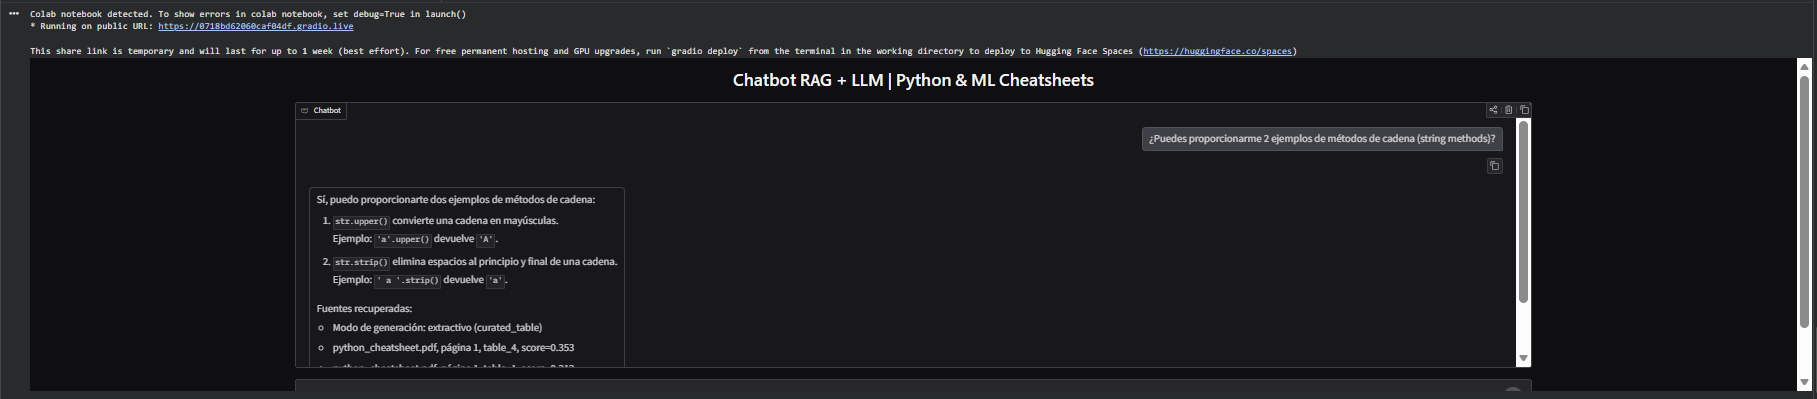

### 12.1 Diagnóstico de scores de fragmentos curados (transparencia del modo extractivo)

Antes de ejecutar las preguntas requeridas, se muestra explícitamente qué `curated_table` resulta más similar a cada pregunta y con qué score, para poder auditar por qué cada pregunta activa o no el modo extractivo guiado (sección 10).

In [14]:
diagnostic_questions = [
    "Según la sección de Exceptions, ¿qué excepción se lanza si divido entre cero?",
    "¿Puedes proporcionarme 2 ejemplos de métodos de cadena o string methods?",
    "¿Cuáles son las principales desventajas de utilizar el modelo Bosque Aleatorio o Random Forests?",
    "¿Cuáles son 3 casos de uso de las técnicas de aprendizaje no supervisado para clustering?",
    "Pregunta adicional Python: ¿Qué funciones puedo usar para revisar el tipo de dato de un objeto en Python?",
    "Pregunta adicional ML: ¿Cuáles son las principales desventajas de K-Means?"
]

diag_rows = []
for q in diagnostic_questions:
    q_emb = embedder.encode([q], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    sims = _curated_embeddings @ q_emb[0]
    best_idx = int(np.argmax(sims))
    diag_rows.append({
        "Pregunta": q[:60] + "...",
        "Mejor curated_table": _curated_chunks[best_idx]["text"][:50] + "...",
        "Score": round(float(sims[best_idx]), 4),
        "¿Activa modo extractivo? (umbral 0.22)": "Sí" if sims[best_idx] >= 0.22 else "No"
    })

pd.DataFrame(diag_rows)

,Pregunta,Mejor curated_table,Score,¿Activa modo extractivo? (umbral 0.22)
0,"Según la sección de Exceptions, ¿qué excepción se lanza si d...",Python Exceptions section. Common exceptions inclu...,0.2942,Sí
1,¿Puedes proporcionarme 2 ejemplos de métodos de cadena o str...,"Python string methods include upper(), lower(), st...",0.2413,Sí
2,¿Cuáles son las principales desventajas de utilizar el model...,Random Forests. Description: An ensemble learning ...,0.4332,Sí
3,¿Cuáles son 3 casos de uso de las técnicas de aprendizaje no...,Unsupervised Learning - Clustering use cases inclu...,0.3575,Sí
4,Pregunta adicional Python: ¿Qué funciones puedo usar para re...,Python data type checking: type() checks the objec...,0.3297,Sí
5,Pregunta adicional ML: ¿Cuáles son las principales desventaj...,K-Means disadvantages: it requires the expected nu...,0.5273,Sí


## 13. Preguntas requeridas de la actividad

In [15]:
required_questions = [
    "Según la sección de Exceptions, ¿qué excepción se lanza si divido entre cero?",
    "¿Puedes proporcionarme 2 ejemplos de métodos de cadena o string methods?",
    "¿Cuáles son las principales desventajas de utilizar el modelo Bosque Aleatorio o Random Forests?",
    "¿Cuáles son 3 casos de uso de las técnicas de aprendizaje no supervisado para clustering?",
    "Pregunta adicional Python: ¿Qué funciones puedo usar para revisar el tipo de dato de un objeto en Python?",
    "Pregunta adicional ML: ¿Cuáles son las principales desventajas de K-Means?"
]

rag_results = []
for q in required_questions:
    ans, src = rag_answer(q, top_k=5, show_sources=True)
    rag_results.append({"Pregunta": q, "Respuesta RAG": ans})
    print("="*100)
    print("PREGUNTA:", q)
    print("\nRESPUESTA:\n", ans)

pd.DataFrame(rag_results)

PREGUNTA: Según la sección de Exceptions, ¿qué excepción se lanza si divido entre cero?

RESPUESTA:
 La excepción que se lanza al dividir por cero es ZeroDivisionError y el mensaje es "No se puede dividir por cero!".

Fuentes recuperadas:
- Modo de generación: extractivo (curated_table)
- python_cheatsheet.pdf, página 2, text, score=0.304
- python_cheatsheet.pdf, página 2, curated_table, score=0.294
- python_cheatsheet.pdf, página 2, table_1, score=0.168
PREGUNTA: ¿Puedes proporcionarme 2 ejemplos de métodos de cadena o string methods?

RESPUESTA:
 Sí, puedo proporcionarte dos ejemplos de métodos de cadena:

1. `str.upper()` convierte una cadena en mayúsculas.
   Ejemplo: `'a'.upper()` devuelve `'A'`.

2. `str.replace(old, new)` reemplaza todas las ocurrencias de `old` con `new`.
   Ejemplo: `'abc'.replace('bc', 'ha')` devuelve `'aha'`.

Fuentes recuperadas:
- Modo de generación: extractivo (curated_table)
- python_cheatsheet.pdf, página 1, table_4, score=0.359
- python_cheatsheet.pdf,

,Pregunta,Respuesta RAG
0,"Según la sección de Exceptions, ¿qué excepción se lanza si divido entre cero?","La excepción que se lanza al dividir por cero es ZeroDivisionError y el mensaje es ""No se puede dividir por cero!"".\n\nFuentes recuperadas:\n- Modo de generación: extractivo (c..."
1,¿Puedes proporcionarme 2 ejemplos de métodos de cadena o string methods?,"Sí, puedo proporcionarte dos ejemplos de métodos de cadena:\n\n1. `str.upper()` convierte una cadena en mayúsculas.\n Ejemplo: `'a'.upper()` devuelve `'A'`.\n\n2. `str.replac..."
2,¿Cuáles son las principales desventajas de utilizar el modelo Bosque Aleatorio o Random Forests?,Las principales desventajas del uso del modelo Bosque Aleatorio o Random Forests incluyen un alto costo de entrenamiento y la falta de interpretabilidad.\n\nFuentes recuperadas...
3,¿Cuáles son 3 casos de uso de las técnicas de aprendizaje no supervisado para clustering?,"Clasificación del público objetivo, análisis de comportamiento y detección de fraude.\n\nFuentes recuperadas:\n- Modo de generación: extractivo (curated_table)\n- ml_cheatsheet..."
4,Pregunta adicional Python: ¿Qué funciones puedo usar para revisar el tipo de dato de un objeto en Python?,"En Python, puedes verificar el tipo de un objeto usando las siguientes funciones:\n\n- `type(objeto)` verifica si el objeto es del tipo especificado.\n- `isinstance(objeto, tip..."
5,Pregunta adicional ML: ¿Cuáles son las principales desventajas de K-Means?,Desventajas clave del K-Means: requiere inicializar previamente la cantidad esperada de clusters y enfrenta problemas con tamaños y densidades de clusters variados.\n\nFuentes ...


## 14. Respuestas finales verificadas

Esta tabla resume las respuestas esperadas para validar que el chatbot no alucinó.

In [16]:
verified_answers = pd.DataFrame([
    {"Pregunta": "Exceptions: división entre cero", "Respuesta verificada": "Se lanza o se captura ZeroDivisionError. En el ejemplo aparece como 'Cannot divide by zero!'."},
    {"Pregunta": "2 métodos de cadena", "Respuesta verificada": "Dos ejemplos son upper() y lower(). También aparecen strip(), replace(), split() y join()."},
    {"Pregunta": "Desventajas de Random Forests", "Respuesta verificada": "La complejidad de entrenamiento puede ser alta y el modelo no es muy interpretable."},
    {"Pregunta": "3 casos de uso de clustering", "Respuesta verificada": "Customer segmentation, recommendation systems y fraud detection. También aparece document clustering based on similarity."},
    {"Pregunta": "Adicional Python", "Respuesta verificada": "Para revisar tipos se puede usar type() y para validar un tipo específico se puede usar isinstance()."},
    {"Pregunta": "Adicional ML", "Respuesta verificada": "K-Means requiere definir el número esperado de clusters desde el inicio y tiene problemas con tamaños y densidades de clusters variables."}
])
verified_answers

,Pregunta,Respuesta verificada
0,Exceptions: división entre cero,Se lanza o se captura ZeroDivisionError. En el ejemplo aparece como 'Cannot divide by zero!'.
1,2 métodos de cadena,"Dos ejemplos son upper() y lower(). También aparecen strip(), replace(), split() y join()."
2,Desventajas de Random Forests,La complejidad de entrenamiento puede ser alta y el modelo no es muy interpretable.
3,3 casos de uso de clustering,"Customer segmentation, recommendation systems y fraud detection. También aparece document clustering based on similarity."
4,Adicional Python,Para revisar tipos se puede usar type() y para validar un tipo específico se puede usar isinstance().
5,Adicional ML,K-Means requiere definir el número esperado de clusters desde el inicio y tiene problemas con tamaños y densidades de clusters variables.


## 15. Manejo de alucinaciones

Se aplicaron las siguientes estrategias:

1. **Restricción de contexto:** el LLM recibe solo fragmentos recuperados de los PDF.
2. **Prompt de seguridad:** se instruye a no inventar y a responder “No tengo suficiente evidencia...” si la información no aparece.
3. **Umbral de similitud:** si el mejor score es bajo, no se genera una respuesta especulativa.
4. **Fuentes visibles:** cada respuesta muestra documento, página, tipo de extracción y score.
5. **Temperatura baja:** se usa generación determinista (`do_sample=False`, `temperature=0.0`).
6. **Capa curada de tablas:** se preservan contenidos tabulares importantes en texto estructurado.
7. **Filtrado de fragmentos ruidosos:** se descartan del contexto fragmentos de tabla mal extraídos (con columnas genéricas `col_1, col_2...`) que aportaban ruido sin información útil.
8. **Modo extractivo guiado:** cuando se recupera un fragmento `curated_table` confiable, la respuesta se genera a partir de ese texto fijo, reduciendo el riesgo de que el LLM mezcle conocimiento externo.

## 16. Análisis técnico

El chatbot implementa una arquitectura RAG clásica. Primero se cargan documentos PDF, se extrae texto con PyMuPDF y tablas con pdfplumber. Después se limpia el contenido, se divide en fragmentos con traslape, se generan embeddings con `all-MiniLM-L6-v2` y se indexan en FAISS para recuperar los fragmentos más similares a cada pregunta. Finalmente, el LLM genera una respuesta en español usando únicamente el contexto recuperado.

El principal reto técnico fue el manejo de tablas. El documento `ml_cheatsheet.pdf` tiene formato de infografía, por lo que algunas tablas se extrajeron con columnas mezcladas o incompletas. Para mitigar esto, se mantuvo la extracción automática, pero también se agregó una capa curada de fragmentos `curated_table` con información clave sobre algoritmos, casos de uso, ventajas y desventajas.

Durante la validación de respuestas se detectó una alucinación parcial en la pregunta sobre Random Forest. Aunque el contexto recuperado contenía la respuesta correcta, el LLM agregó desventajas genéricas que no estaban en los documentos. Esto mostró que un prompt restrictivo no siempre es suficiente, especialmente con modelos pequeños que ya tienen conocimiento previo sobre temas comunes de Machine Learning.

Para corregirlo, se aplicaron tres mejoras principales: se reforzó el prompt para priorizar el contexto, se filtraron fragmentos ruidosos de tablas mal extraídas y se implementó un modo extractivo guiado. En este modo, cuando existe un fragmento `curated_table` con alta similitud, el sistema no permite una respuesta libre, sino que pide al modelo resumir o traducir literalmente ese fragmento. Además, la búsqueda de fragmentos curados se separó del retrieval general, comparando cada pregunta contra todos los `curated_table` disponibles.

Esta estrategia mejoró la fidelidad de las respuestas, especialmente en preguntas sobre Random Forest, K-Means, excepciones y métodos de cadena. También se agregó una celda de diagnóstico para revisar el fragmento curado más cercano y su score de similitud, lo cual permite auditar si una respuesta fue generada con suficiente evidencia.

## 17. Conclusiones


El chatbot RAG + LLM permitió responder preguntas técnicas a partir de documentos PDF usando recuperación semántica y generación controlada. FAISS fue suficiente para localizar fragmentos relevantes en una colección pequeña de documentos, mientras que el LLM permitió presentar respuestas naturales en español.

El principal aprendizaje fue que la calidad de extracción del contenido es crítica en sistemas RAG. Los documentos con texto lineal fueron más fáciles de procesar, mientras que las tablas e infografías requirieron una capa curada para preservar información estructurada importante.

También se comprobó que mitigar alucinaciones no depende únicamente de escribir mejores prompts. En algunos casos fue necesario modificar la arquitectura de respuesta, usando un modo extractivo guiado para preguntas con evidencia curada confiable. Esto ayudó a reducir respuestas plausibles pero no fundamentadas.

Como trabajo futuro, se podrían agregar métricas cuantitativas de recuperación como precision@k, evaluación automática de fidelidad al contexto, OCR para documentos escaneados y revisión humana periódica para preguntas críticas.

# Fin de la actividad chatbot: LLM + RAG